# 房价预测 EDA 报告

本 notebook 用于探索 Kaggle House Prices 数据集，重点观察目标变量、缺失值、特征相关性、类别特征差异和潜在异常点，为后续特征工程和建模提供依据。

## 主要发现

- 训练集规模为 `1460 x 81`，测试集规模为 `1459 x 80`。
- 预测目标列是 `SalePrice`，表示房屋最终售价。
- `SalePrice` 呈明显右偏分布，因此对目标变量使用 `log1p` 变换更适合本比赛的评价方式。
- 与 `SalePrice` 关系较强的数值特征包括 `OverallQual`、`GrLivArea`、`GarageCars`、`GarageArea`、`TotalBsmtSF` 和 `1stFlrSF`。
- 缺失较多的列往往表示某类设施不存在，例如泳池、小巷通道、围栏、壁炉和车库相关属性。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.shape, test.shape

((1460, 81), (1459, 80))

## 数据集概览

In [2]:
overview = pd.DataFrame(
    {
        "数据集": ["训练集", "测试集"],
        "行数": [len(train), len(test)],
        "列数": [train.shape[1], test.shape[1]],
        "数值列数量": [train.select_dtypes(include="number").shape[1], test.select_dtypes(include="number").shape[1]],
        "类别列数量": [train.select_dtypes(exclude="number").shape[1], test.select_dtypes(exclude="number").shape[1]],
    }
)
overview

,数据集,行数,列数,数值列数量,类别列数量
0,训练集,1460,81,38,43
1,测试集,1459,80,37,43


In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 目标变量分布

本比赛的评分基于房价对数误差，而原始 `SalePrice` 明显右偏。对 `SalePrice` 使用 `log1p` 变换后，目标分布更接近对称，通常能让线性模型和正则化模型更稳定。

In [4]:
target_summary = train["SalePrice"].describe().rename(
    {
        "count": "样本数",
        "mean": "均值",
        "std": "标准差",
        "min": "最小值",
        "25%": "25%分位数",
        "50%": "中位数",
        "75%": "75%分位数",
        "max": "最大值",
    }
).to_frame().T
target_summary["偏度"] = train["SalePrice"].skew()
target_summary

,样本数,均值,标准差,最小值,25%分位数,中位数,75%分位数,最大值,偏度
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0,1.882876


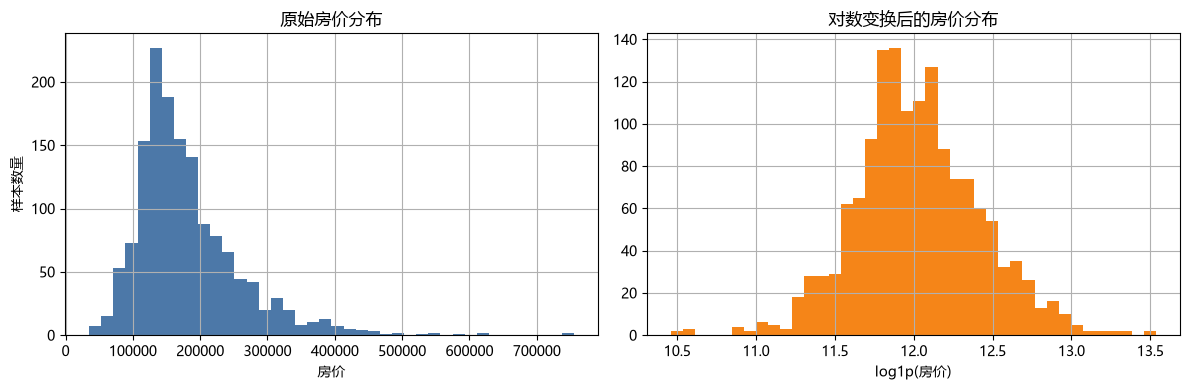

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train["SalePrice"].hist(bins=40, ax=axes[0], color="#4C78A8")
axes[0].set_title("原始房价分布")
axes[0].set_xlabel("房价")
axes[0].set_ylabel("样本数量")

np.log1p(train["SalePrice"]).hist(bins=40, ax=axes[1], color="#F58518")
axes[1].set_title("对数变换后的房价分布")
axes[1].set_xlabel("log1p(房价)")

plt.tight_layout()

## 缺失值分析

部分缺失值不是普通的数据缺口，而是有业务含义的类别。例如 `PoolQC`、`Alley`、`Fence`、`FireplaceQu` 以及车库相关字段的缺失，通常表示该房屋没有对应设施。建模时可以将这些缺失值编码为 `None` 或类似的“无该设施”类别。

In [6]:
missing = (
    train.isna().sum()
    .rename("缺失数量")
    .to_frame()
    .assign(缺失比例=lambda df: df["缺失数量"] / len(train) * 100)
    .query("缺失数量 > 0")
    .sort_values("缺失数量", ascending=False)
)
missing.head(20)

,缺失数量,缺失比例
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


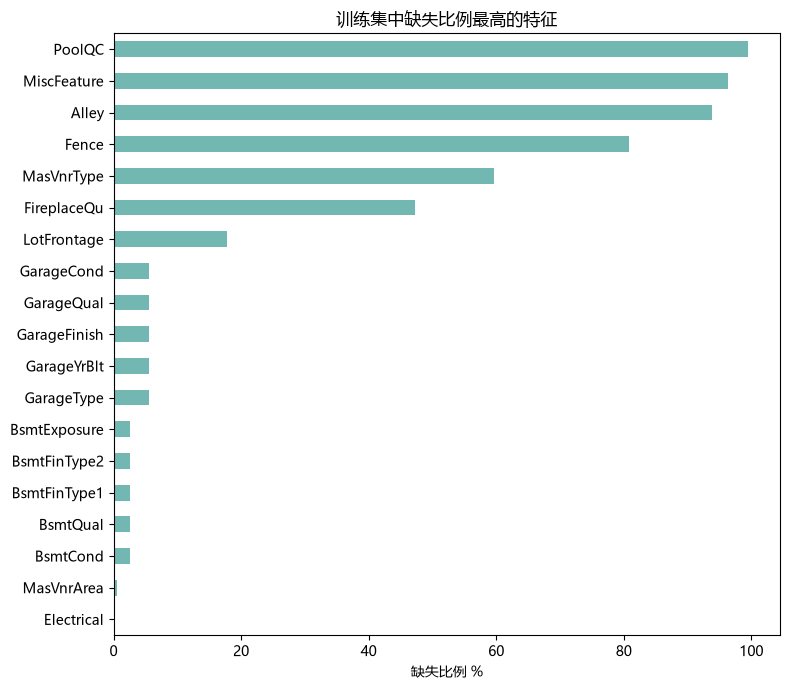

In [7]:
top_missing = missing.head(20).sort_values("缺失数量")
ax = top_missing["缺失比例"].plot(kind="barh", figsize=(8, 7), color="#72B7B2")
ax.set_title("训练集中缺失比例最高的特征")
ax.set_xlabel("缺失比例 %")
ax.set_ylabel("")
plt.tight_layout()

## 数值特征相关性

`OverallQual` 和地上居住面积是最强的简单数值信号。车库容量、车库面积、地下室面积和一层面积等规模类特征，也与房价存在明显正相关关系。

In [8]:
corr = train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(15).to_frame("与房价的相关系数")

,与房价的相关系数
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


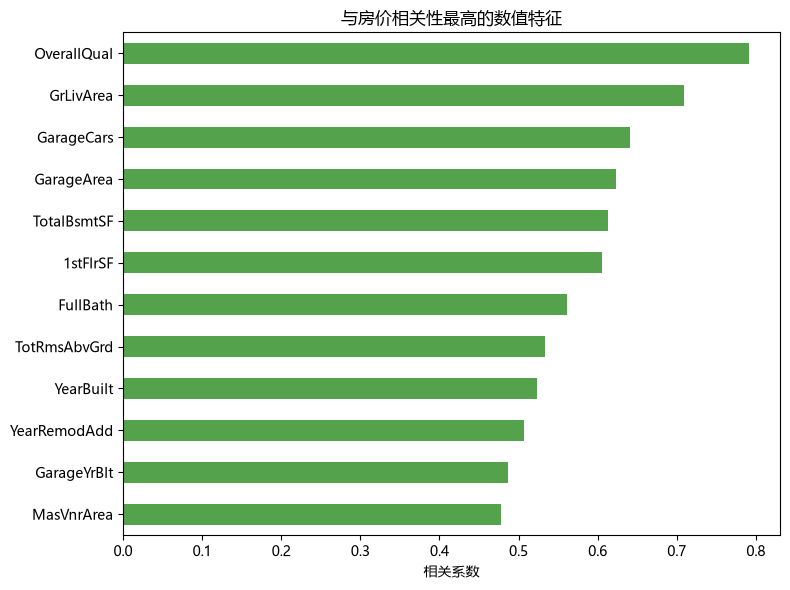

In [9]:
top_corr = corr.drop("SalePrice").head(12).sort_values()
ax = top_corr.plot(kind="barh", figsize=(8, 6), color="#54A24B")
ax.set_title("与房价相关性最高的数值特征")
ax.set_xlabel("相关系数")
ax.set_ylabel("")
plt.tight_layout()

## 重要数值特征关系

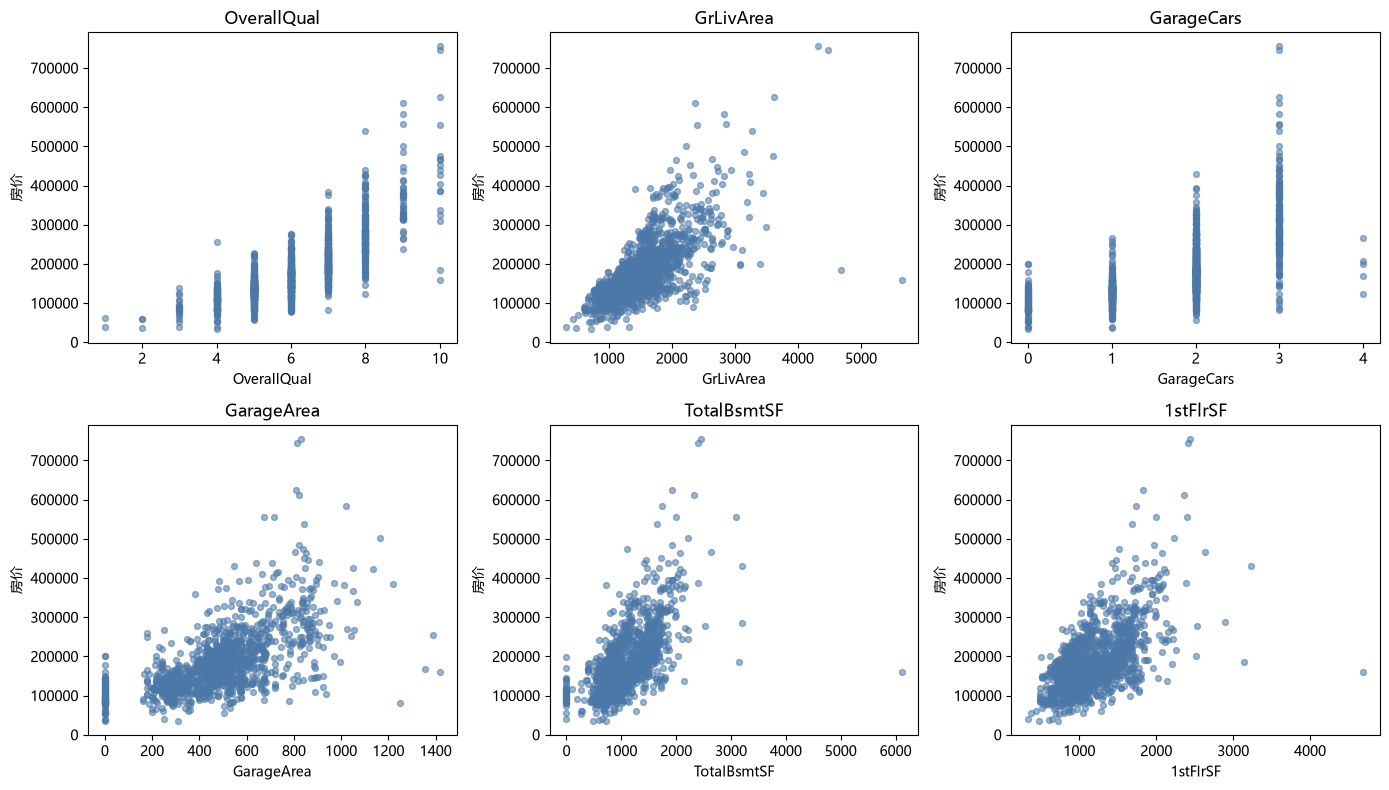

In [10]:
features = ["OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF", "1stFlrSF"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feature in zip(axes.ravel(), features):
    ax.scatter(train[feature], train["SalePrice"], alpha=0.55, s=18, color="#4C78A8")
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("房价")

plt.tight_layout()

## 类别特征信号

类别特征也包含明显价格信号。例如不同 `Neighborhood` 的房价中位数差异很大，说明地段信息非常重要。后续建模时，类别特征不应简单丢弃，而应该使用合适的编码方式。

In [11]:
neighborhood_price = (
    train.groupby("Neighborhood")["SalePrice"]
    .agg(样本数="count", 中位数="median", 均值="mean")
    .sort_values("中位数", ascending=False)
)
neighborhood_price

,样本数,中位数,均值
Neighborhood,,,
NridgHt,77,315000.0,316270.623377
NoRidge,41,301500.0,335295.317073
StoneBr,25,278000.0,310499.000000
Timber,38,228475.0,242247.447368
Somerst,86,225500.0,225379.837209
Veenker,11,218000.0,238772.727273
Crawfor,51,200624.0,210624.725490
ClearCr,28,200250.0,212565.428571
CollgCr,150,197200.0,197965.773333


C:\Users\84740\AppData\Local\Temp\ipykernel_10536\2085875761.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, tick_labels=ordered_neighborhoods, vert=False, showfliers=False)


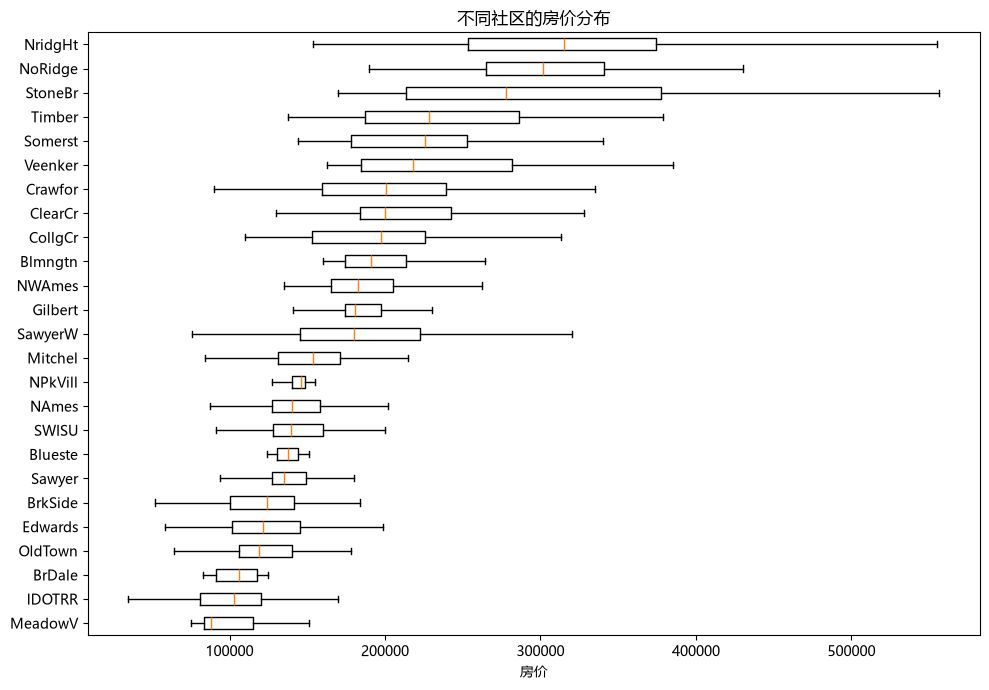

In [12]:
ordered_neighborhoods = neighborhood_price.sort_values("中位数").index
data = [train.loc[train["Neighborhood"] == n, "SalePrice"] for n in ordered_neighborhoods]

fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot(data, tick_labels=ordered_neighborhoods, vert=False, showfliers=False)
ax.set_title("不同社区的房价分布")
ax.set_xlabel("房价")
ax.set_ylabel("")
plt.tight_layout()

## 异常值检查

`GrLivArea` 中存在少量面积很大但售价相对较低的样本。这类点可能影响线性模型的拟合效果，因此在最终建模前需要重点检查，必要时可以做异常值处理或稳健建模。

In [13]:
train.loc[
    (train["GrLivArea"] > 4000) | (train["SalePrice"] > 600000),
    ["Id", "SalePrice", "GrLivArea", "OverallQual", "Neighborhood", "YearBuilt"],
].sort_values("GrLivArea", ascending=False)

,Id,SalePrice,GrLivArea,OverallQual,Neighborhood,YearBuilt
1298,1299,160000,5642,10,Edwards,2008
523,524,184750,4676,10,Edwards,2007
1182,1183,745000,4476,10,NoRidge,1996
691,692,755000,4316,10,NoRidge,1994
1169,1170,625000,3627,10,NoRidge,1995
898,899,611657,2364,9,NridgHt,2009


## 建模建议

- 使用 `log1p(SalePrice)` 作为训练目标，预测后再用 `expm1` 还原到原始房价尺度。
- 对许多类别特征的缺失值，优先按“没有该设施”处理，而不是直接当作普通缺失。
- 可以构造总面积、总浴室数、房龄、翻新年限、门廊和露台总面积等衍生特征。
- 建议先用 one-hot 编码配合 Ridge、Lasso、ElasticNet 建立稳定基线，再尝试梯度提升树模型。
- 使用交叉验证评估，并让验证指标与比赛的 RMSLE 评价方式保持一致。